In [9]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [16]:
class GenerativePEPS():
    def __init__(self, N, D, p, use_torch = False, rng = None):
        self.N = N;
        self.D = D;
        self.p = p;
        self.use_torch = use_torch;
        if rng is None:
            rng = np.random.default_rng()
        self.tensors = rng.standard_normal((N, N, D, D, D, D, p)) * 0.1
        print(f"params per tensor: {D**4 * p}")
        print(f"total params:      {N * N * D**4 * p}")
        
    def InitiPeps(self, rng = None):
        return tensors
    
    def ContractPEPS(self):
        noise_map = np.zeros((self.N, self.N))
    
        # Initialize the top boundary: one D-dim vector per column
        boundary = np.ones((self.N, self.D)) / self.D
    
        for row in range(N):
            # Open left boundary for each new row
            left_vec = np.zeros(self.D)
            left_vec[0] = 1.0
    
            for col in range(N):
                T = self.tensors[row, col]        # Shape: (D, D, D, D, p)
                up_vec = boundary[col]       # Shape: (D,)
    
                # Contract left and up vectors simultaneously.
                # l: left, r: right, u: up, d: down
                # We output a matrix of shape (r, d) which contains the un-normalized 
                # right and down vectors coupled together.
                out_rd = np.einsum('lrud,l,u->rd', T[..., 0], left_vec, up_vec)
                
                # Read out the scalar for the noise map (e.g., r=0, d=0)
                noise_map[row, col] = out_rd[0, 0]
    
                # Decouple the (r, d) output into separate right and down vectors.
                # A simple sum across the opposite axis works for this causal method.
                new_right = np.sum(out_rd, axis=1) # Sum out 'd' to get 'r'
                new_down = np.sum(out_rd, axis=0)  # Sum out 'r' to get 'd'
    
                # Normalize and pass to the next tensors
                left_vec = new_right / (np.linalg.norm(new_right) + 1e-10)
                boundary[col] = new_down / (np.linalg.norm(new_down) + 1e-10)
    
        return noise_map

params per tensor: 16
total params:      2304

Top left 5x5 of the noise map:
[[0.604 0.526 0.495 0.548 0.423]
 [0.727 0.616 0.149 0.75  0.552]
 [0.281 0.809 0.595 0.449 0.474]
 [0.33  0.628 0.321 0.405 0.347]
 [0.365 0.353 0.351 0.561 0.581]]


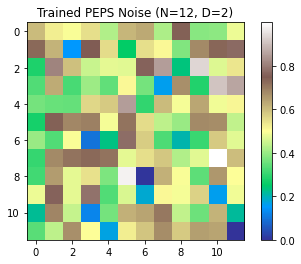

In [ ]:
N = 12
D = 2
p = 1
rng = np.random.default_rng(42)
peps = GenerativePEPS(N, D, p, False, rng)

# Now uses the inferred N and D safely
raw_map = peps.ContractPEPS()

display_map = (raw_map - raw_map.min()) / (raw_map.max() - raw_map.min() + 1e-10)
print("\nTop left 5x5 of the noise map:")
print(np.round(display[:5, :5], 3))
plt.imshow(display_map, cmap='terrain')
plt.colorbar()
plt.title(f"PEPS Noise (N={N}, D={D})")
plt.show()